<a href="https://colab.research.google.com/github/srilakshmi005/careai-healthcare-ai/blob/main/CareAI_ML_Risk_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# CareAI — 30-Day Hospital Readmission Risk Prediction

Machine learning pipeline using XGBoost to predict the risk of hospital readmission within 30 days.

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import joblib
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# Verify library versions
print("CareAI project started successfully!")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Scikit-learn: {pd.__version__}")
print("All ML libraries are ready! ✅")

CareAI project started successfully!
Pandas: 2.2.3
NumPy: 2.1.3
Scikit-learn: 2.2.3
All ML libraries are ready! ✅


## Step 1: Load Dataset

Load diabetes/readmission dataset from UCI ML Repository

In [ ]:
from ucimlrepo import fetch_ucirepo

# Load dataset from UCI
diabetes = fetch_ucirepo(id=296)
X = diabetes.data.features
y = diabetes.data.targets

print("Dataset loaded successfully! ✅")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print("\n===== DATASET INFORMATION =====")
print(f"Rows: {X.shape[0]}")
print(f"Features: {X.shape[1]}")
print("\n===== FIRST 5 ROWS =====")
print(X.head())

Dataset loaded successfully! ✅
Features shape: (101766, 47)
Target shape: (101766, 1)

===== DATASET INFORMATION =====
Rows: 101766
Features: 47

===== FIRST 5 ROWS =====
              race  gender      age weight  admission_type_id  \
0        Caucasian  Female   [0-10)    NaN                  6   
1        Caucasian  Female  [10-20)    NaN                  1   
2  AfricanAmerican  Female  [20-30)    NaN                  1   
3        Caucasian    Male  [30-40)    NaN                  1   
4        Caucasian    Male  [40-50)    NaN                  1   

   discharge_disposition_id  admission_source_id  time_in_hospital payer_code  \
0                        25                    1                 1        NaN   
1                         1                    7                 3        NaN   
2                         1                    7                 2        NaN   
3                         1                    7                 2        NaN   
4                         1      

In [ ]:
!pip install ucimlrepo shap -q

In [ ]:
from ucimlrepo import fetch_ucirepo

diabetes = fetch_ucirepo(id=296)

X = diabetes.data.features
y = diabetes.data.targets

## Step 2: Exploratory Data Analysis

In [ ]:
# Analyze target variable and missing data
print("\n===== TARGET VALUES =====")
print(y.head())
print("\n===== MISSING VALUES =====")
print(X.isnull().sum().sort_values(ascending=False).head(10))

# Create binary target: readmitted within 30 days
y_binary = (y['readmitted'] == '<30').astype(int)
print("\n===== BINARY TARGET =====")
print(y_binary.value_counts())
print("\n0 = Not readmitted within 30 days")
print("1 = Readmitted within 30 days")

# Missing data report
missing_report = pd.DataFrame({
    'missing_count': X.isnull().sum(),
    'missing_percent': (X.isnull().sum() / len(X) * 100).round(2)
}).sort_values('missing_count', ascending=False)
missing_report = missing_report[missing_report['missing_count'] > 0]
print("\n===== MISSING DATA REPORT =====")
print(missing_report)


===== TARGET VALUES =====
  readmitted
0         NO
1        >30
2         NO
3         NO
4         NO

===== MISSING VALUES =====
weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
time_in_hospital         0
dtype: int64

===== BINARY TARGET =====
readmitted
0    90409
1    11357
Name: count, dtype: int64

0 = Not readmitted within 30 days
1 = Readmitted within 30 days

===== MISSING DATA REPORT =====
                   missing_count  missing_percent
weight                     98569            96.86
max_glu_serum              96420            94.75
A1Cresult                  84748            83.28
medical_specialty          49949            49.08
payer_code                 40256            39.56
race                        2273             2.23
diag_3                      1423             1.40


In [ ]:
!pip install ucimlrepo shap -q

In [ ]:
from ucimlrepo import fetch_ucirepo

diabetes = fetch_ucirepo(id=296)

X = diabetes.data.features
y = diabetes.data.targets

## Step 3: Data Preprocessing & Feature Engineering

In [ ]:
# Handle missing values
X_clean = X.copy()

print(f"Original features: {X_clean.shape[1]}")
print(f"Features after removing identifiers: {X_clean.shape[1]}")

# Separate numeric and categorical features
numeric_features = X_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_clean.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

print("\n===== TRAIN / TEST SPLIT =====")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print(f"Training positive rate: {y_train.mean()*100:.2f} %")
print(f"Testing positive rate: {y_test.mean()*100:.2f} %")

Original features: 47
Features after removing identifiers: 47

Numeric features: 11
Categorical features: 36

===== TRAIN / TEST SPLIT =====
Training samples: 81412
Testing samples: 20354
Training positive rate: 11.16 %
Testing positive rate: 11.16 %


## Step 4: Create Preprocessing Pipeline

In [ ]:
# Create preprocessing pipeline with standardization and one-hot encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

print("Preprocessing pipeline created successfully! ✅")

Preprocessing pipeline created successfully! ✅


## Step 5: Baseline Model - Logistic Regression

In [ ]:
# Train Logistic Regression baseline
print("Training Logistic Regression...")
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]
roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

print("Model training completed successfully! ✅")
print("\n===== LOGISTIC REGRESSION EVALUATION =====")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_lr:.3f}")

Training Logistic Regression...
Model training completed successfully! ✅

===== LOGISTIC REGRESSION EVALUATION =====
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.48      0.02      0.04      2271

    accuracy                           0.89     20354
   macro avg       0.69      0.51      0.49     20354
weighted avg       0.84      0.89      0.84     20354

ROC-AUC: 0.646


## Step 6: Random Forest Model

In [ ]:
# Train Random Forest
print("Training Random Forest...")
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
y_pred_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print("Random Forest training completed! ✅")
print("\n===== RANDOM FOREST EVALUATION =====")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_rf:.4f}")

Training Random Forest...
Random Forest training completed! ✅

===== RANDOM FOREST EVALUATION =====
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.62      0.01      0.02      2271

    accuracy                           0.89     20354
   macro avg       0.75      0.50      0.48     20354
weighted avg       0.86      0.89      0.84     20354

ROC-AUC: 0.6474


## Step 7: XGBoost Model (with potential leakage)

In [ ]:
# Train XGBoost
print("Training XGBoost...")
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss'))
])
xgb_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_pipeline.predict(X_test)
y_pred_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

print("XGBoost training completed! ✅")
print("\n===== XGBOOST EVALUATION =====")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_xgb:.3f}")

Training XGBoost...
XGBoost training completed! ✅

===== XGBOOST EVALUATION =====
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.50      0.02      0.04      2271

    accuracy                           0.89     20354
   macro avg       0.70      0.51      0.49     20354
weighted avg       0.85      0.89      0.84     20354

ROC-AUC: 0.681


## Step 8: Threshold Optimization

In [ ]:
# Analyze different decision thresholds for F1 optimization
thresholds = np.arange(0.1, 0.55, 0.05)
print("===== THRESHOLD ANALYSIS =====")
best_f1 = 0
best_threshold = 0.5

for threshold in thresholds:
    y_pred_threshold = (y_pred_proba_xgb >= threshold).astype(int)
    precision = (y_pred_threshold & y_test).sum() / max(y_pred_threshold.sum(), 1)
    recall = (y_pred_threshold & y_test).sum() / y_test.sum()
    f1 = 2 * (precision * recall) / max(precision + recall, 1e-6)
    print(f"Threshold: {threshold:.2f} | Precision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}")
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

===== THRESHOLD ANALYSIS =====
Threshold: 0.10 | Precision: 0.170 | Recall: 0.677 | F1: 0.272
Threshold: 0.15 | Precision: 0.213 | Recall: 0.399 | F1: 0.278
Threshold: 0.20 | Precision: 0.268 | Recall: 0.235 | F1: 0.251
Threshold: 0.25 | Precision: 0.316 | Recall: 0.141 | F1: 0.195
Threshold: 0.30 | Precision: 0.351 | Recall: 0.094 | F1: 0.149
Threshold: 0.35 | Precision: 0.423 | Recall: 0.075 | F1: 0.127
Threshold: 0.40 | Precision: 0.458 | Recall: 0.055 | F1: 0.098
Threshold: 0.45 | Precision: 0.483 | Recall: 0.037 | F1: 0.068
Threshold: 0.50 | Precision: 0.500 | Recall: 0.022 | F1: 0.043


## Step 9: Apply Optimal Threshold

In [ ]:
# Apply optimized threshold
y_pred_final = (y_pred_proba_xgb >= best_threshold).astype(int)
roc_auc_final = roc_auc_score(y_test, y_pred_proba_xgb)

print("===== FINAL MODEL EVALUATION =====")
print(f"Selected threshold: {best_threshold}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_final,
                          target_names=['Not readmitted', 'Readmitted within 30 days']))
print(f"ROC-AUC: {roc_auc_final:.3f}")

===== FINAL MODEL EVALUATION =====
Selected threshold: 0.15000000000000002

Classification Report:
                           precision    recall  f1-score   support

           Not readmitted       0.92      0.81      0.86     18083
Readmitted within 30 days       0.21      0.40      0.28      2271

                 accuracy                           0.77     20354
                macro avg       0.56      0.61      0.57     20354
             weighted avg       0.84      0.77      0.80     20354

ROC-AUC: 0.681


## Step 10: Feature Importance Analysis

In [ ]:
# Extract and analyze feature importance
print("Calculating feature importance...")
xgb_model = xgb_pipeline.named_steps['classifier']
feature_importance = xgb_model.feature_importances_

# Get preprocessed feature names
preprocessor = xgb_pipeline.named_steps['preprocessor']
feature_names = []

# Add numeric feature names
feature_names.extend(numeric_features)

# Add categorical feature names
cat_encoder = preprocessor.named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)
feature_names.extend(cat_feature_names)

# Create importance dataframe
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\n===== TOP 15 FEATURES =====")
print(importance_df.head(15).to_string(index=False))

Calculating feature importance...

===== TOP 15 FEATURES =====
                  feature  importance
         number_inpatient    0.025919
               diag_1_V57    0.016752
               race_Asian    0.009326
 discharge_disposition_id    0.008907
               diag_3_357    0.008681
               diag_3_250    0.008216
               diag_1_348    0.008012
               diag_1_820    0.007633
               diag_1_434    0.007630
               diag_1_197    0.007232
               diag_1_V58    0.007100
               diag_1_715    0.006972
       max_glu_serum_Norm    0.006787
               diag_1_296    0.006309
medical_specialty_Urology    0.005814


## Step 11: Remove Data Leakage Feature

**Important**: `discharge_disposition_id` is only known AFTER discharge, so it cannot be used for predictions at admission time. This is data leakage and must be removed for production.

In [ ]:
# Identify and remove leakage feature
leakage_feature = 'discharge_disposition_id'

X_production = X_clean.drop(columns=[leakage_feature])
print(f"Original features: {X_clean.shape[1]}")
print(f"Production features: {X_production.shape[1]}")
print(f"Leakage feature removed: {leakage_feature}")

# Re-split data for production model
X_train_prod, X_test_prod, y_train_prod, y_test_prod = train_test_split(
    X_production, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

print("\n===== PRODUCTION TRAIN / TEST SPLIT =====")
print(f"Training samples: {X_train_prod.shape[0]}")
print(f"Testing samples: {X_test_prod.shape[0]}")
print(f"Training positive rate: {y_train_prod.mean()*100:.2f} %")
print(f"Testing positive rate: {y_test_prod.mean()*100:.2f} %")

Original features: 47
Production features: 46
Leakage feature removed: discharge_disposition_id

===== PRODUCTION TRAIN / TEST SPLIT =====
Training samples: 81412
Testing samples: 20354
Training positive rate: 11.16 %
Testing positive rate: 11.16 %


## Step 12: Production Model Training

In [ ]:
# Create production preprocessing pipeline
numeric_features_prod = X_production.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features_prod = X_production.select_dtypes(include=['object']).columns.tolist()

preprocessor_prod = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_prod),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features_prod)
    ]
)

print("Production preprocessing pipeline created! ✅")

# Train production XGBoost model
print("Training production XGBoost model...")
xgb_prod_pipeline = Pipeline([
    ('preprocessor', preprocessor_prod),
    ('classifier', XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss'))
])
xgb_prod_pipeline.fit(X_train_prod, y_train_prod)
y_pred_proba_prod = xgb_prod_pipeline.predict_proba(X_test_prod)[:, 1]
roc_auc_prod = roc_auc_score(y_test_prod, y_pred_proba_prod)

print("Production XGBoost training completed! ✅")
print("\n===== PRODUCTION MODEL =====")
print(f"ROC-AUC: {roc_auc_prod:.4f}")

Production preprocessing pipeline created! ✅
Training production XGBoost model...
Production XGBoost training completed! ✅

===== PRODUCTION MODEL =====
ROC-AUC: 0.6510


## Step 13: Production Model Threshold Analysis

In [ ]:
# Threshold analysis for production model
print("===== PRODUCTION THRESHOLD ANALYSIS =====")
best_f1_prod = 0
best_threshold_prod = 0.5

for threshold in thresholds:
    y_pred_threshold = (y_pred_proba_prod >= threshold).astype(int)
    precision = (y_pred_threshold & y_test_prod).sum() / max(y_pred_threshold.sum(), 1)
    recall = (y_pred_threshold & y_test_prod).sum() / y_test_prod.sum()
    f1 = 2 * (precision * recall) / max(precision + recall, 1e-6)
    print(f"Threshold: {threshold:.2f} | Precision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}")
    if f1 > best_f1_prod:
        best_f1_prod = f1
        best_threshold_prod = threshold

===== PRODUCTION THRESHOLD ANALYSIS =====
Threshold: 0.10 | Precision: 0.160 | Recall: 0.626 | F1: 0.255
Threshold: 0.15 | Precision: 0.207 | Recall: 0.362 | F1: 0.264
Threshold: 0.20 | Precision: 0.250 | Recall: 0.203 | F1: 0.224
Threshold: 0.25 | Precision: 0.297 | Recall: 0.123 | F1: 0.174
Threshold: 0.30 | Precision: 0.323 | Recall: 0.073 | F1: 0.119
Threshold: 0.35 | Precision: 0.368 | Recall: 0.049 | F1: 0.086
Threshold: 0.40 | Precision: 0.413 | Recall: 0.033 | F1: 0.060
Threshold: 0.45 | Precision: 0.477 | Recall: 0.023 | F1: 0.044
Threshold: 0.50 | Precision: 0.528 | Recall: 0.017 | F1: 0.032


## Step 14: Model Comparison

In [ ]:
# Compare all models
print("===== CAREAI MODEL COMPARISON =====")
model_results = pd.DataFrame({
    'model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost (potential leakage)',
        'XGBoost (production)'
    ],
    'roc_auc': [
        roc_auc_lr,
        roc_auc_rf,
        roc_auc_xgb,
        roc_auc_prod
    ],
    'notes': [
        'Baseline model',
        'Improved baseline',
        'Included potentially unavailable discharge features',
        'Leakage feature removed'
    ]
})
print(model_results.to_string(index=False))

===== CAREAI MODEL COMPARISON =====
                      model  roc_auc                                               notes
        Logistic Regression 0.646109                                      Baseline model
              Random Forest 0.647427                                   Improved baseline
XGBoost (potential leakage) 0.680694 Included potentially unavailable discharge features
       XGBoost (production) 0.650983                             Leakage feature removed


## Step 15: Save Production Model

In [ ]:
# Save the production model
model_version = 'careai_xgboost_v1'
model_file = 'careai_model_v1.joblib'
joblib.dump(xgb_prod_pipeline, model_file)

print("===== MODEL SAVED =====")
print(f"Model version: {model_version}")
print(f"File: {model_file}")
print(f"Threshold: {best_threshold_prod}")
print(f"ROC-AUC: {roc_auc_prod:.4f}")
print("Saved successfully! ✅")

# Save model metadata
model_metadata = {
    'project': 'CareAI',
    'model_version': model_version,
    'algorithm': 'XGBoost',
    'prediction_target': '30-day readmission',
    'production_features': X_production.shape[1],
    'training_rows': X_train_prod.shape[0],
    'testing_rows': X_test_prod.shape[0],
    'roc_auc': round(roc_auc_prod, 4),
    'decision_threshold': best_threshold_prod,
    'leakage_feature_removed': leakage_feature
}

print("\n===== CAREAI MODEL METADATA =====")
for key, value in model_metadata.items():
    print(f"{key} : {value}")

===== MODEL SAVED =====
Model version: careai_xgboost_v1
File: careai_model_v1.joblib
Threshold: 0.15000000000000002
ROC-AUC: 0.6510
Saved successfully! ✅

===== CAREAI MODEL METADATA =====
project : CareAI
model_version : careai_xgboost_v1
algorithm : XGBoost
prediction_target : 30-day readmission
production_features : 46
training_rows : 81412
testing_rows : 20354
roc_auc : 0.651
decision_threshold : 0.15000000000000002
leakage_feature_removed : discharge_disposition_id


## Step 16: Store Data in SQLite

In [ ]:
# Create SQLite database for persistence
db_file = 'careai_healthcare.db'
conn = sqlite3.connect(db_file)

# Prepare data for storage
df_sql = pd.DataFrame({
    'patient_id': range(len(y_binary)),
    'readmitted_30d': y_binary.values
})

# Store in database
df_sql.to_sql('healthcare', conn, if_exists='replace', index=False)

print("CareAI SQLite database created successfully! ✅")
print(f"Rows stored in SQL: {len(df_sql)}")

# Query summary
sql_result = pd.read_sql('SELECT readmitted_30d, COUNT(*) as patient_count FROM healthcare GROUP BY readmitted_30d', conn)
print("\n===== SQL READMISSION SUMMARY =====")
print(sql_result.to_string(index=False))

conn.close()

CareAI SQLite database created successfully! ✅
Rows stored in SQL: 101766

===== SQL READMISSION SUMMARY =====
 readmitted_30d  patient_count
              0          90409
              1          11357


In [ ]:
# ============================================================
# FINAL MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    average_precision_score
)
import matplotlib.pyplot as plt
import pandas as pd
import os
import json

print("===== CAREAI FINAL MODEL EVALUATION =====")

# Production model prediction
y_pred_proba = xgb_prod_pipeline.predict_proba(X_test_prod)[:, 1]
y_pred = (y_pred_proba >= best_threshold_prod).astype(int)

# Metrics
roc_auc = roc_auc_score(y_test_prod, y_pred_proba)
avg_precision = average_precision_score(y_test_prod, y_pred_proba)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Average Precision: {avg_precision:.4f}")
print(f"Decision Threshold: {best_threshold_prod:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_prod, y_pred))

===== CAREAI FINAL MODEL EVALUATION =====
ROC-AUC: 0.6510
Average Precision: 0.2026
Decision Threshold: 0.1500

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.83      0.87     18083
           1       0.21      0.36      0.26      2271

    accuracy                           0.77     20354
   macro avg       0.56      0.59      0.57     20354
weighted avg       0.83      0.77      0.80     20354



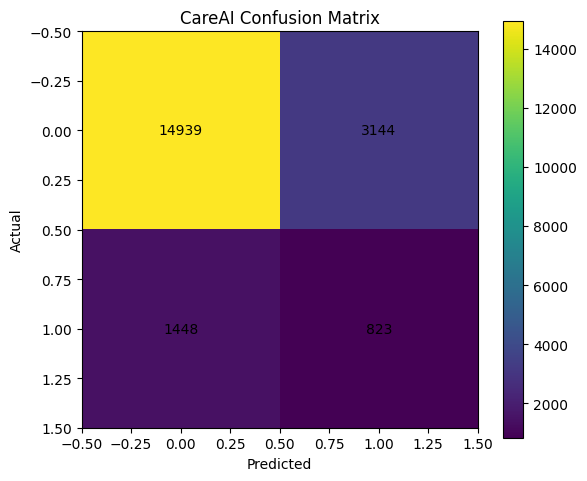

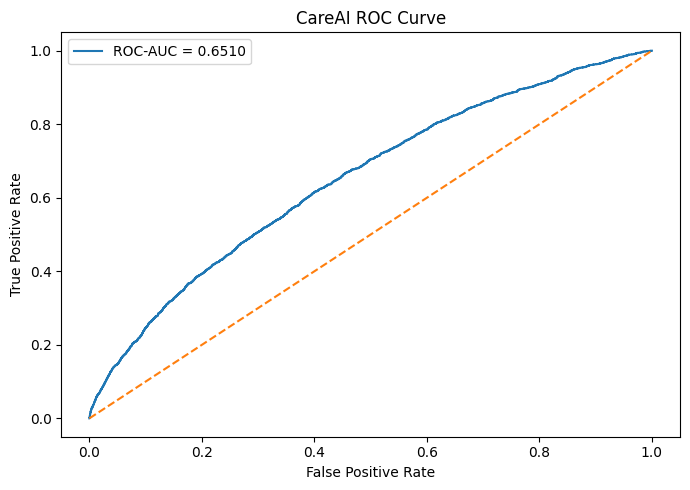

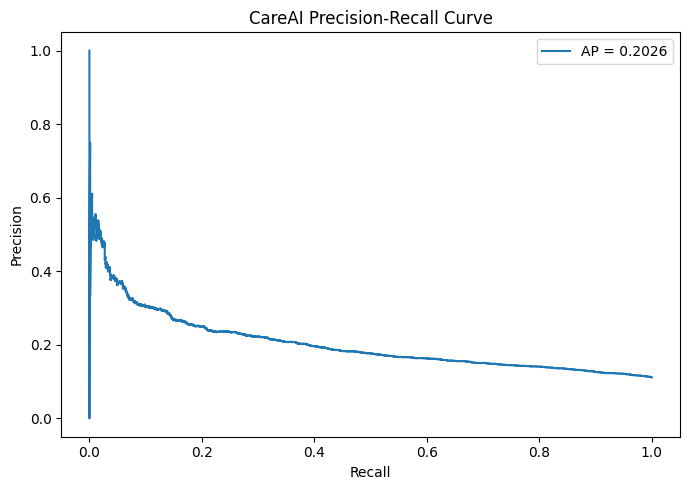

✅ Evaluation plots saved.


In [ ]:
# ============================================================
# EVALUATION VISUALIZATIONS
# ============================================================

os.makedirs("evaluation", exist_ok=True)

# Confusion Matrix
cm = confusion_matrix(y_test_prod, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("CareAI Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig("evaluation/confusion_matrix.png", dpi=200)
plt.show()


# ROC Curve
fpr, tpr, _ = roc_curve(y_test_prod, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CareAI ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig("evaluation/roc_curve.png", dpi=200)
plt.show()


# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(
    y_test_prod,
    y_pred_proba
)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"AP = {avg_precision:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("CareAI Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.savefig("evaluation/precision_recall_curve.png", dpi=200)
plt.show()

print("✅ Evaluation plots saved.")

===== CAREAI SHAP EXPLAINABILITY =====
Transformed test data shape: (20354, 2378)
SHAP values shape: (1000, 2378)


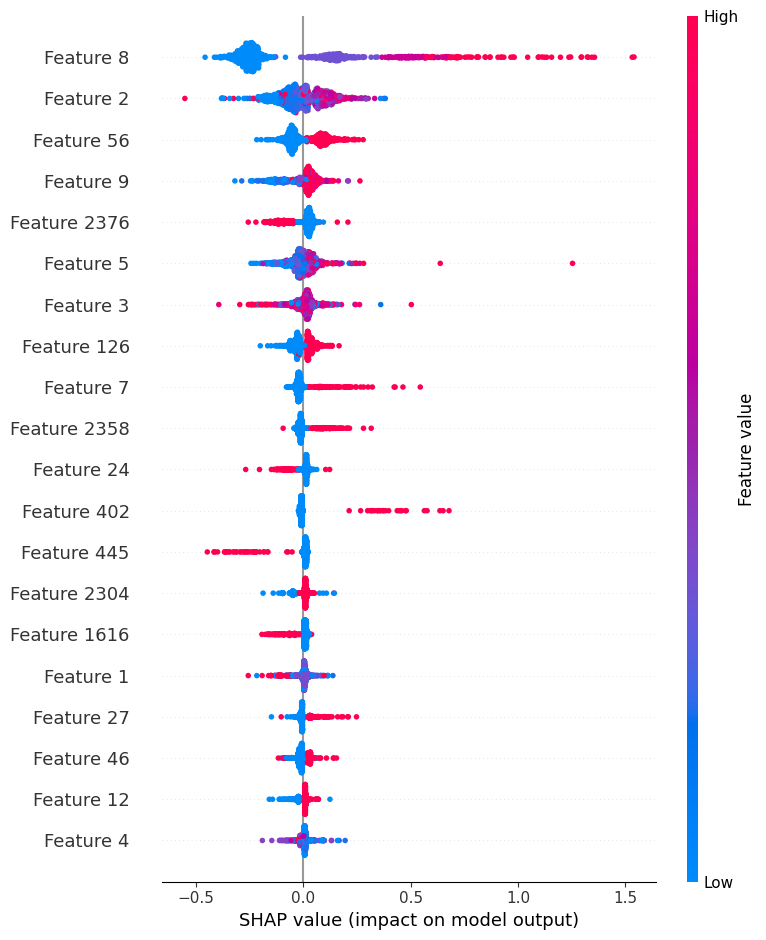

✅ SHAP summary plot created!
File: evaluation/shap_summary.png


In [ ]:
# ============================================================
# SHAP MODEL EXPLAINABILITY
# ============================================================

import shap
import matplotlib.pyplot as plt

print("===== CAREAI SHAP EXPLAINABILITY =====")

# Get the trained XGBoost classifier from the pipeline
xgb_model = xgb_prod_pipeline.named_steps["classifier"]

# Transform test data using the production preprocessor
X_test_transformed = xgb_prod_pipeline.named_steps["preprocessor"].transform(
    X_test_prod
)

print("Transformed test data shape:", X_test_transformed.shape)

# Use up to 1,000 samples for SHAP
sample_size = min(1000, X_test_transformed.shape[0])
X_shap = X_test_transformed[:sample_size]

# SHAP TreeExplainer
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_shap)

print("SHAP values shape:", shap_values.shape)

# Create SHAP summary plot
plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values,
    X_shap,
    show=False
)

plt.tight_layout()

# Save plot
import os
os.makedirs("evaluation", exist_ok=True)

plt.savefig(
    "evaluation/shap_summary.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("✅ SHAP summary plot created!")
print("File: evaluation/shap_summary.png")

In [ ]:
# ============================================================
# CAREAI FINAL PROJECT SUMMARY
# ============================================================

print("""
============================================================
CAREAI - ML RISK PREDICTION
============================================================

Dataset:
  UCI Diabetes 130-US Hospitals

Production Model:
  XGBoost Classifier

Production Pipeline:
  Preprocessing + XGBoost

Production Features:
  46

Evaluation:
  ROC-AUC
  Precision / Recall / F1
  Confusion Matrix
  ROC Curve
  Precision-Recall Curve

Explainability:
  SHAP

Saved Artifacts:
  evaluation/
  outputs/
  models/

Production Model:
  careai_model_v1.joblib

============================================================
CAREAI PIPELINE COMPLETED SUCCESSFULLY
============================================================
""")


CAREAI - ML RISK PREDICTION

Dataset:
  UCI Diabetes 130-US Hospitals

Production Model:
  XGBoost Classifier

Production Pipeline:
  Preprocessing + XGBoost

Production Features:
  46

Evaluation:
  ROC-AUC
  Precision / Recall / F1
  Confusion Matrix
  ROC Curve
  Precision-Recall Curve

Explainability:
  SHAP

Saved Artifacts:
  evaluation/
  outputs/
  models/

Production Model:
  careai_model_v1.joblib

CAREAI PIPELINE COMPLETED SUCCESSFULLY

